# Détecteur de fraude - Analyse

## Objectifs

* Comprendre la construction du dataset

In [1]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:
# Lecture des fichiers
print("Loading dataset...")

__file__ = os.path.abspath("EDA.ipynb")  # Simuler __file__ dans un notebook

# Définir le chemin absolu du modèle
dataset_path = os.path.join(
    os.path.dirname(__file__), "..", "data", "fraudTest.csv"
)
dataset_path = os.path.normpath(dataset_path)
# os.path.dirname(__file__) permet de partir du dossier où se trouve app.py.
# .. remonte d’un niveau pour atteindre la racine du projet.

dataset = pd.read_csv(dataset_path, index_col=0)

print("...Done.")

Loading dataset...
...Done.


## Analye descriptive

In [3]:
## Analyse descriptive
# INFORMATIONS GENERALES
print("\n INFORMATIONS GENERALES")
print("-" * 40)

print("Nombre de lignes (nb de transactions): {}".format(dataset.shape[0]))
print("Nombre de colonnes : {}".format(dataset.shape[1]))
print("Nombre de fraudes : {}".format(dataset["is_fraud"].sum()))

print("Aperçu du dataset : ")
display(dataset.head())

print("Types de données/colonnes : ")
display(dataset.dtypes)


 INFORMATIONS GENERALES
----------------------------------------
Nombre de lignes (nb de transactions): 555719
Nombre de colonnes : 22
Nombre de fraudes : 2145
Aperçu du dataset : 


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


Types de données/colonnes : 


trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

NameError: name 'dataset' is not defined

In [ ]:
# VALEURS MANQUANTES
print("\n VALEURS MANQUANTES")
print("-" * 40)

print("Nombre de valeurs manquantes par colonne :")
missing_values = dataset.isnull().sum()
missing_values_percentage = ((missing_values / dataset.shape[0]) * 100).round(
    2
)
missing_df = pd.DataFrame(
    {
        "Valeurs manquantes": missing_values,
        "Pourcentage": missing_values_percentage,
    }
)
print(missing_df[missing_df["Valeurs manquantes"] > 0])

# CONVERSION VALEURS NUMERIQUES
# Convertir la colonne en format datetime
dataset["trans_date_trans_time"] = pd.to_datetime(dataset["trans_date_trans_time"])

# Convertir Date en année / semaine / jour de semaine
dataset["Year"] = dataset["trans_date_trans_time"].dt.year
dataset["Month"] = dataset["trans_date_trans_time"].dt.month
dataset["Day"] = dataset["trans_date_trans_time"].dt.day
dataset["Weekday"] = dataset["trans_date_trans_time"].dt.weekday  # 0 = Lundi, 6 = Dimanche
dataset['Hour'] = dataset['trans_date_trans_time'].dt.hour



 VALEURS MANQUANTES
----------------------------------------
Nombre de valeurs manquantes par colonne :
Empty DataFrame
Columns: [Valeurs manquantes, Pourcentage]
Index: []


In [5]:
# STATISTIQUES DESCRIPTIVES
# Statistiques descriptives globales
print("Statistiques descriptives globales :")
display(dataset.describe(include="all").round(2))

Statistiques descriptives globales :


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,Year,Month,Day,Weekday
count,555719,5.557190e+05,555719,555719,555719.00,555719,555719,555719,555719,555719,...,555719,555719,5.557190e+05,555719.00,555719.00,555719.00,555719.0,555719.00,555719.00,555719.00
unique,NaN,NaN,693,14,NaN,341,471,2,924,849,...,910,555719,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,444 Robert Mews,Birmingham,...,1977-03-23,2da90c7d74bd46a0caf3777415b3ebd3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1859,56370,NaN,11443,12146,304886,1474,2423,...,2408,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2020-10-02 01:54:25.166780672,4.178387e+17,NaN,NaN,69.39,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.380679e+09,38.54,-90.23,0.00,2020.0,9.51,16.46,2.73
min,2020-06-21 12:14:25,6.041621e+10,NaN,NaN,1.00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.371817e+09,19.03,-166.67,0.00,2020.0,6.00,1.00,0.00
25%,2020-08-09 06:10:27.500000,1.800429e+14,NaN,NaN,9.63,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.376029e+09,34.76,-96.91,0.00,2020.0,8.00,9.00,1.00
50%,2020-10-03 00:59:48,3.521417e+15,NaN,NaN,47.29,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.380762e+09,39.38,-87.45,0.00,2020.0,10.00,17.00,2.00
75%,2020-12-01 03:03:04,4.635331e+15,NaN,NaN,83.01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.385867e+09,41.95,-80.26,0.00,2020.0,12.00,24.00,5.00
max,2020-12-31 23:59:34,4.992346e+18,NaN,NaN,22768.11,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.388534e+09,66.68,-66.95,1.00,2020.0,12.00,31.00,6.00


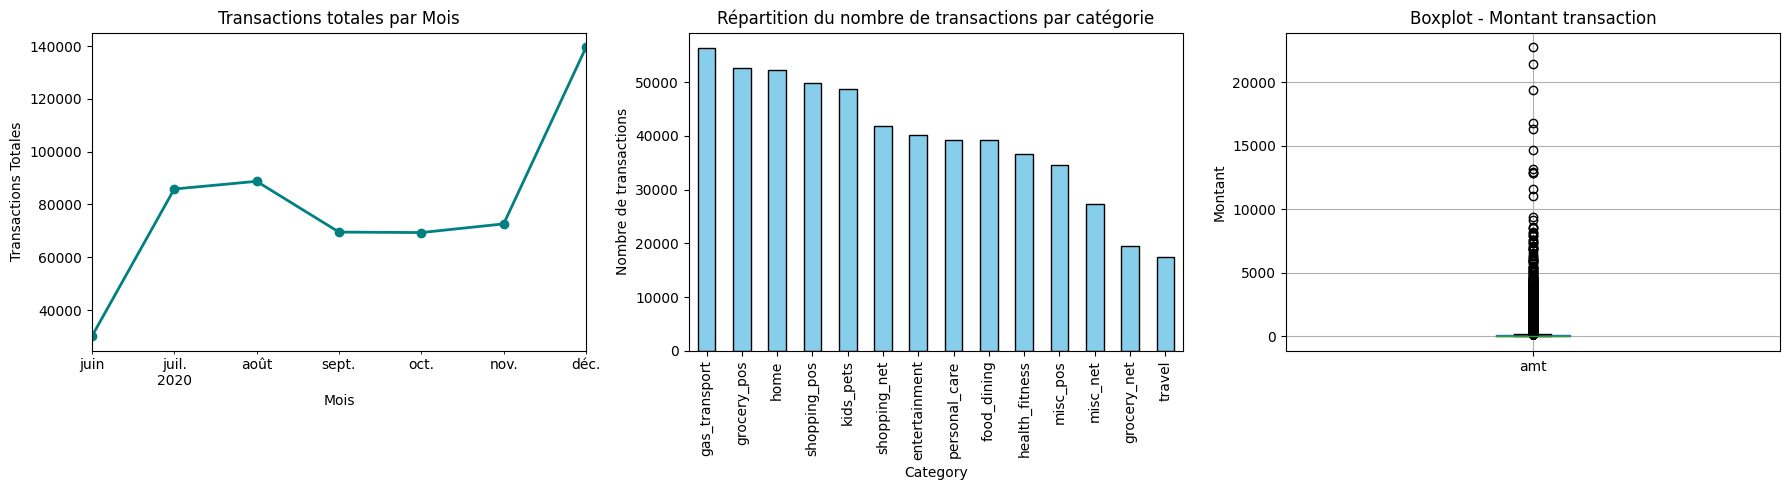

In [ ]:
# DESCRIPTION DES VARIABLES
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Variable "ventes_par_mois"
dataset['Month_Year'] = dataset['trans_date_trans_time'].dt.to_period('M')
trans_par_mois = dataset.groupby('Month_Year').size()
ax = trans_par_mois.plot(kind="line", marker='o', linestyle='-', color='teal', linewidth=2, ax=axes[0])

axes[0].set_title("Transactions totales par Mois")
axes[0].set_xlabel("Mois")
axes[0].set_ylabel("Transactions Totales")
axes[0].tick_params(axis="x", rotation=45)

# Variable "category"
# Calculer la fréquence par catégorie
cat_freq = dataset["category"].value_counts()
ax = cat_freq.plot(kind="bar", color="skyblue", edgecolor="black", ax=axes[1])

axes[1].set_title("Répartition du nombre de transactions par catégorie")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Nombre de transactions")

# Boxplot - "amt"
dataset.boxplot(column="amt", ax=axes[2])
axes[2].set_title("Boxplot - Montant transaction")
axes[2].set_ylabel("Montant")

plt.tight_layout()
plt.show()

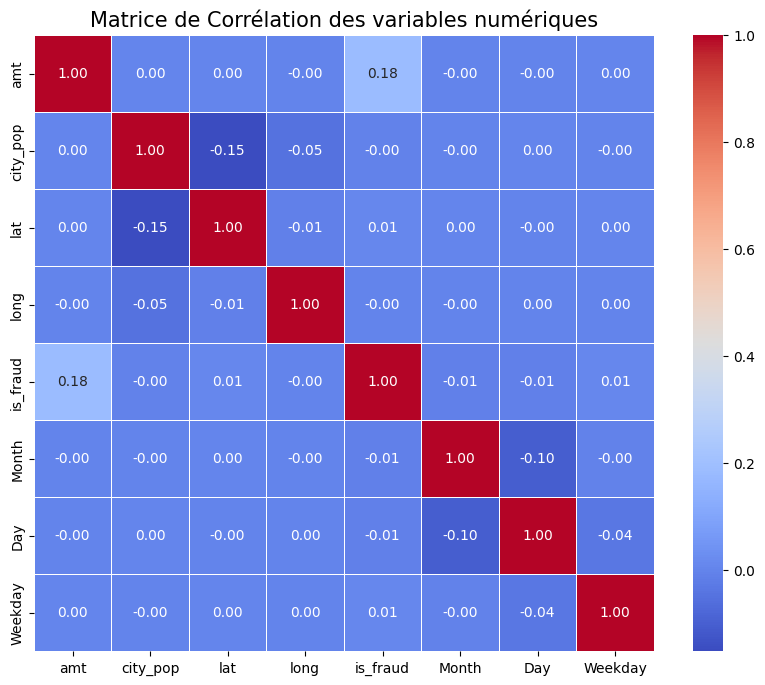

In [ ]:
# HEATMAP globale
# Calcul de la matrice de corrélation
# Sélection des variables numériques pertinentes
cols_to_corr = ['amt', 'city_pop', 'lat', 'long', 'is_fraud', 'Month', 'Day', 'Weekday']

# Calcul de la matrice
corr_matrix = dataset[cols_to_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Matrice de Corrélation des variables numériques", fontsize=15)
plt.show()

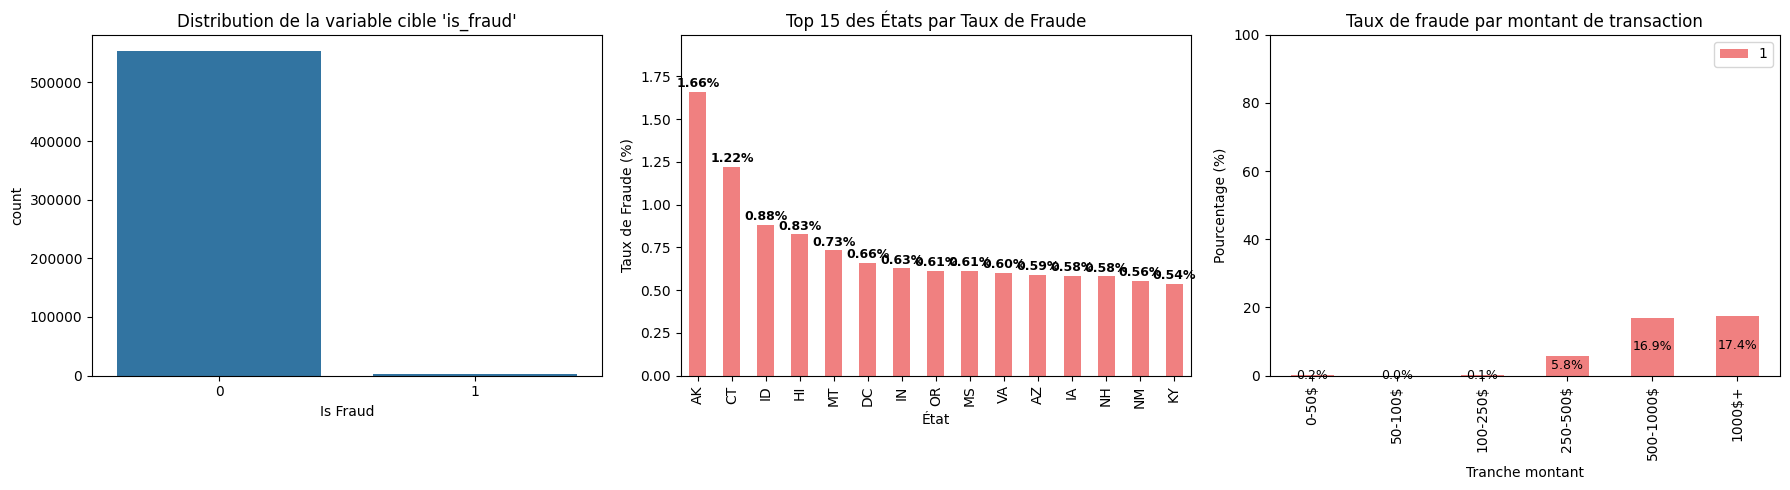

Taux de fraud (en pourcentage) : 0.39 %
category
shopping_net     1.21
misc_net         0.98
grocery_pos      0.92
shopping_pos     0.43
gas_transport    0.27
Name: is_fraud, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Countplot is_fraud
sns.countplot(x="is_fraud", data=dataset, ax=axes[0])
axes[0].set_title("Distribution de la variable cible 'is_fraud'")
axes[0].set_xlabel("Is Fraud")
axes[0].set_ylabel("count")

# Taux de fraud par pays
fraud_par_pays = pd.crosstab(dataset["state"], dataset["is_fraud"], normalize="index") * 100
fraud_serie = fraud_par_pays[1].sort_values(ascending=False)
fraud_serie = fraud_serie.head(15)

fraud_serie.plot(
    kind="bar", 
    ax=axes[1], 
    color="lightcoral"
)

axes[1].set_ylabel("Taux de Fraude (%)")
axes[1].set_xlabel("État")
axes[1].set_title("Top 15 des États par Taux de Fraude")
axes[1].set_ylim(0, fraud_serie.max() * 1.2) # Ajuste dynamiquement le haut du graph

# Ajouter les labels au-dessus des barres
for p in axes[1].patches:
    axes[1].text(
        p.get_x() + p.get_width() / 2,
        p.get_y() + p.get_height() + 0.01, # Un peu au-dessus de la barre
        f"{p.get_height():.2f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight='bold'
    )

# Taux de fraud par montant
bins = [0, 50, 100, 250, 500, 1000, dataset["amt"].max()]
labels = ["0-50$", "50-100$", "100-250$", "250-500$", "500-1000$", "1000$+"]
dataset["amount_group"] = pd.cut(dataset["amt"], bins=bins, labels=labels)

fraud_par_montant = (
    pd.crosstab(dataset["amount_group"], dataset["is_fraud"], normalize="index")
    * 100
)

ax = fraud_par_montant[1].plot(kind="bar", color="lightcoral", ax=axes[2])

axes[2].set_ylabel("Pourcentage (%)")
axes[2].set_xlabel("Tranche montant")
axes[2].set_title("Taux de fraude par montant de transaction")
axes[2].legend(title="", loc="upper right")
axes[2].set_ylim(0, 100)

# Ajouter les valeurs
for p in axes[2].patches:
    if p.get_height() > 0:
        axes[2].text(
            p.get_x() + p.get_width() / 2,
            p.get_y() + p.get_height() / 2,
            f"{p.get_height():.1f}%",
            ha="center",
            va="center",
            fontsize=9,
        )

# Ajustement
plt.tight_layout()
plt.show()

# Taux de fraud
taux_fraud = (dataset["is_fraud"].mean() * 100).round(2)
print(f"Taux de fraud (en pourcentage) : {taux_fraud} %")

# Voir le TOP 5 des catégories les plus risquées
print(dataset.groupby('category')['is_fraud'].mean().sort_values(ascending=False).head(5).multiply(100).round(2))

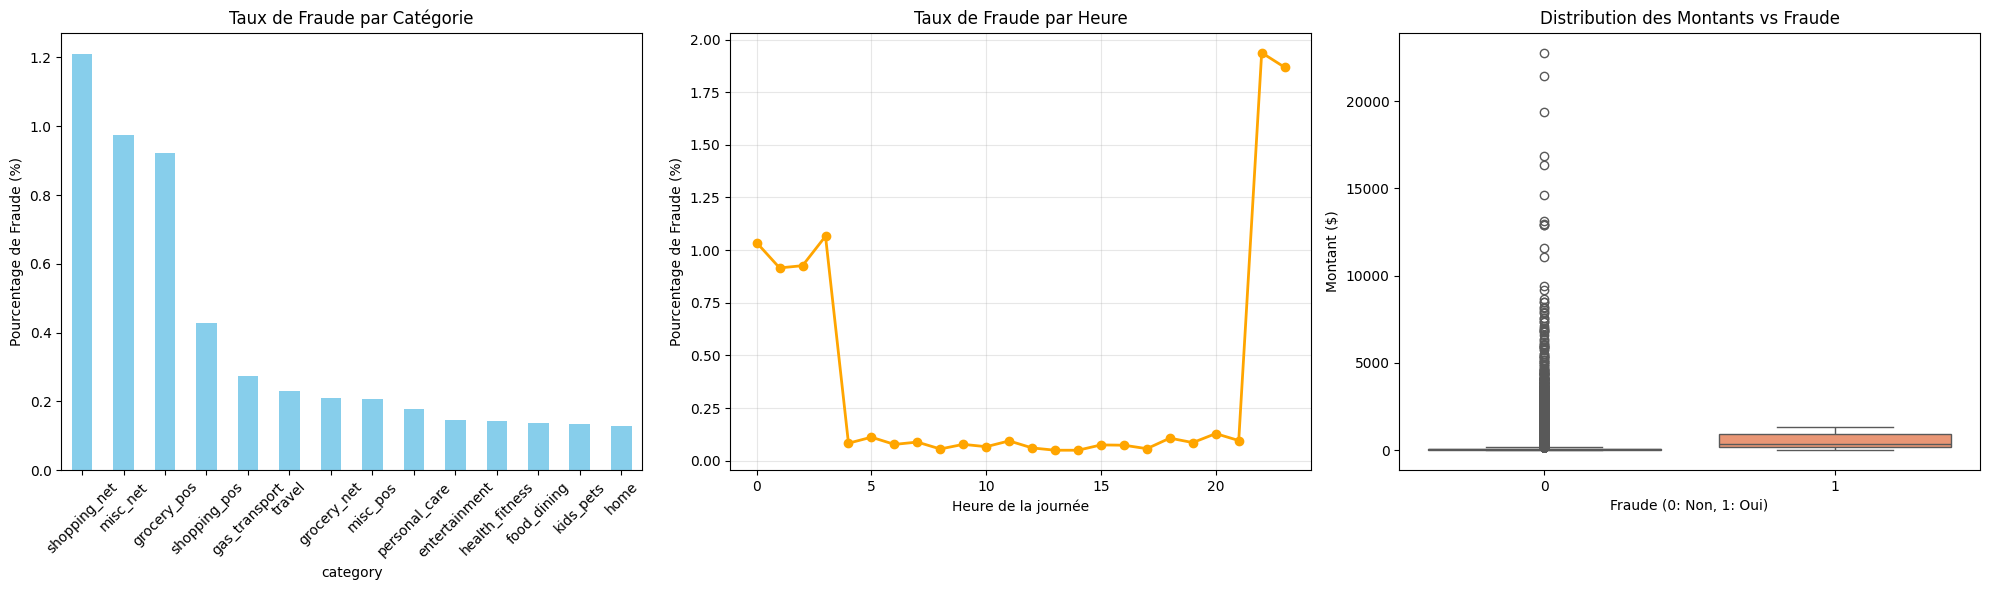

In [39]:
# Création de la figure (1 ligne, 3 colonnes)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# GRAPH 1 : Crosstab Catégorie (Taux de fraude) ---
cross_cat = pd.crosstab(dataset["category"], dataset["is_fraud"], normalize="index")[1] * 100
cross_cat.sort_values(ascending=False).plot(kind="bar", ax=axes[0], color="skyblue")
axes[0].set_title("Taux de Fraude par Catégorie")
axes[0].set_ylabel("Pourcentage de Fraude (%)")
axes[0].tick_params(axis='x', rotation=45)

# GRAPH 2 : Crosstab Heure (Taux de fraude) ---
cross_hour = pd.crosstab(dataset["Hour"], dataset["is_fraud"], normalize="index")[1] * 100
cross_hour.plot(kind="line", marker="o", ax=axes[1], color="orange", linewidth=2)
axes[1].set_title("Taux de Fraude par Heure")
axes[1].set_ylabel("Pourcentage de Fraude (%)")
axes[1].set_xlabel("Heure de la journée")
axes[1].grid(True, alpha=0.3)

# GRAPH 3 : Boxplot (Montant vs Fraude) ---
# Variante :utiliser showfliers=False pour ignorer les points aberrants extrêmes 
sns.boxplot(x="is_fraud", y="amt", data=dataset, ax=axes[2], palette="Set2", showfliers=True)
axes[2].set_title("Distribution des Montants vs Fraude")
axes[2].set_xlabel("Fraude (0: Non, 1: Oui)")
axes[2].set_ylabel("Montant ($)")

plt.tight_layout()
plt.show()

## **Synthèse**

- 0.39 % de fraudes sur le nombre de transactions
- Les clients réalisant des opérations bancaires depuis les Etats-Unis ont plus de risque d'être concernés (Etats Alaska, Connecticut, Idaho, Hawaï)
- Les fraudes sont plus importantes sur des montants au-delà de 500 $

Risque de fraude
- Les achats en ligne (e-commerce, 1.21% de fraude et achats divers, 0.98%) et effectués en magasins (grocery_pos, 0.92% et shopping_pos, 0.43%) sont plus exposés à la fraude 
- Les fraudes sont plus élevées pendant la nuit (22h-4h)
- Les paiements qui ne sont pas des fraudes ont des montants très variables

_Rq:_ La matrice de corrélation ne tient pas compte des variables catégorielles.